In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
sales = pd.read_csv('/Users/Zhuanz/Downloads/m5-forecasting-accuracy/sales_train_validation.csv')
calendar = pd.read_csv('/Users/Zhuanz/Downloads/m5-forecasting-accuracy/calendar.csv')
prices = pd.read_csv('/Users/Zhuanz/Downloads/m5-forecasting-accuracy/sell_prices.csv')

# Pre-processing

In [3]:
sales = sales.iloc[:, :1000]

In [4]:
df = pd.melt(
    sales,
    id_vars=['id','item_id','dept_id','cat_id','store_id','state_id'],
    var_name='d',
    value_name='sales'
)

In [5]:
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [6]:
df = df.merge(calendar, on='d', how='left')

In [7]:
df = df.merge(
    prices,
    on=['store_id','item_id','wm_yr_wk'],
    how='left'
)

In [8]:
df['sales'] = pd.to_numeric(df['sales'])

In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type == 'object':
            df[col] = df[col].astype('category')
            
        elif str(col_type).startswith('int'):
            df[col] = pd.to_numeric(df[col], downcast='integer')
            
        elif str(col_type).startswith('float'):
            df[col] = pd.to_numeric(df[col], downcast='float')
            
    return df

df = reduce_mem_usage(df)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30307060 entries, 0 to 30307059
Data columns (total 22 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            category      
 1   item_id       category      
 2   dept_id       category      
 3   cat_id        category      
 4   store_id      category      
 5   state_id      category      
 6   d             category      
 7   sales         int16         
 8   date          datetime64[ns]
 9   wm_yr_wk      int16         
 10  weekday       category      
 11  wday          int8          
 12  month         int8          
 13  year          int16         
 14  event_name_1  category      
 15  event_type_1  category      
 16  event_name_2  category      
 17  event_type_2  category      
 18  snap_CA       int8          
 19  snap_TX       int8          
 20  snap_WI       int8          
 21  sell_price    float32       
dtypes: category(12), datetime64[ns](1), float32(1), int16(3), int8(5

In [12]:
cols_to_drop = [col for col in df.columns if col.endswith('_x') or col.endswith('_y')]
df.drop(columns=cols_to_drop, inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30307060 entries, 0 to 30307059
Data columns (total 22 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            category      
 1   item_id       category      
 2   dept_id       category      
 3   cat_id        category      
 4   store_id      category      
 5   state_id      category      
 6   d             category      
 7   sales         int16         
 8   date          datetime64[ns]
 9   wm_yr_wk      int16         
 10  weekday       category      
 11  wday          int8          
 12  month         int8          
 13  year          int16         
 14  event_name_1  category      
 15  event_type_1  category      
 16  event_name_2  category      
 17  event_type_2  category      
 18  snap_CA       int8          
 19  snap_TX       int8          
 20  snap_WI       int8          
 21  sell_price    float32       
dtypes: category(12), datetime64[ns](1), float32(1), int16(3), int8(5

In [14]:
# filter first
df = df[df['store_id'] == 'CA_1']

In [15]:
#Date Feature Engineering

In [16]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week
df['dayofweek'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

In [17]:
df = df.sort_values(['id','date'])
g = df.groupby('id', observed=False)['sales']
df['lag_7'] = g.shift(7)
df['lag_14'] = g.shift(14)
df['lag_28'] = g.shift(28)

In [18]:
df['rolling_mean_7'] = g.shift(1).rolling(7).mean()
df['rolling_mean_30'] = g.shift(1).rolling(30).mean()
df['rolling_std_7'] = g.shift(1).rolling(7).std()

In [19]:
#Encode Categorical Variables

df['store_avg_sales'] = df.groupby('store_id')['sales'].transform('mean')
df['dept_avg_sales'] = df.groupby('dept_id')['sales'].transform('mean')

/var/folders/nt/zwsk_dtn0rsbm3nb5p2fw1_w0000gp/T/ipykernel_32583/496760915.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['store_avg_sales'] = df.groupby('store_id')['sales'].transform('mean')
/var/folders/nt/zwsk_dtn0rsbm3nb5p2fw1_w0000gp/T/ipykernel_32583/496760915.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['dept_avg_sales'] = df.groupby('dept_id')['sales'].transform('mean')


In [20]:
#Encode Categorical Variables
cat_cols = ['item_id','dept_id','cat_id','store_id','state_id']
for col in cat_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

In [21]:
# Fill missing values (numeric only)
num_cols = df.select_dtypes(include=['int64','float64','int32','float32']).columns
df[num_cols] = df[num_cols].fillna(0)

In [22]:
# Fill missing values (numeric only)
df.drop(
    ['event_name_1','event_name_2','event_type_1','event_type_2'],
    axis=1,
    inplace=True
)

In [23]:
df.shape

(3030706, 30)

In [24]:
# Drop all remaining object/string columns
df = df.drop(columns=df.select_dtypes(include='object').columns)

# Train

In [46]:
split_date = df['date'].max() - pd.Timedelta(days=28)
train = df[df['date'] <= split_date]
test = df[df['date'] > split_date]

In [47]:
df.drop(columns=['d', 'day','id'], errors='ignore', inplace=True)

In [48]:
# Drop all remaining string/object columns (weekday, etc.)
df = df.drop(columns=df.select_dtypes(include='object').columns)

In [49]:
target = "sales"
features = [c for c in df.columns if c not in ["sales", "date"]]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [50]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [51]:
num_cols = X_train.select_dtypes(include=['int64','float64','int32','float32']).columns

cat_cols = []

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import GradientBoostingRegressor

import lightgbm as lgb

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), X_train.columns)],
    remainder="drop"  
)

In [54]:
X_train.dtypes

item_id              int64
dept_id              int64
cat_id               int64
store_id             int64
state_id             int64
wm_yr_wk             int16
wday                  int8
month                int32
year                 int32
snap_CA               int8
snap_TX               int8
snap_WI               int8
sell_price         float32
week                UInt32
dayofweek            int32
quarter              int32
is_weekend           int64
lag_7              float64
lag_14             float64
lag_28             float64
rolling_mean_7     float64
rolling_mean_30    float64
rolling_std_7      float64
store_avg_sales    float64
dept_avg_sales     float64
dtype: object

In [55]:
models = {

"Linear Regression": LinearRegression(),

"Random Forest": RandomForestRegressor(
    n_estimators=50,
    max_depth=8,
    random_state=42
),

"Gradient Boosting": GradientBoostingRegressor(
    n_estimators=100
),

"XGBoost": XGBRegressor(
    n_estimators=150,
    max_depth=6
),

"LightGBM": lgb.LGBMRegressor(
    n_estimators=150
)

}

In [56]:
results = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    print(f"Training {name}")

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results[name] = [mae, rmse]

Training Linear Regression
Training Random Forest
Training Gradient Boosting
Training XGBoost
Training LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1811
[LightGBM] [Info] Number of data points in the train set: 2945334, number of used features: 22
[LightGBM] [Info] Start training from score 1.213105


/opt/anaconda3/envs/recsys/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [57]:
results_df = pd.DataFrame(
    results,
    index=["MAE","RMSE"]
).T

print(results_df.sort_values("RMSE"))

                        MAE      RMSE
LightGBM           0.987585  2.735801
Gradient Boosting  0.998301  2.745169
Random Forest      0.996918  2.770547
Linear Regression  1.023121  2.778737
XGBoost            0.988437  2.873778


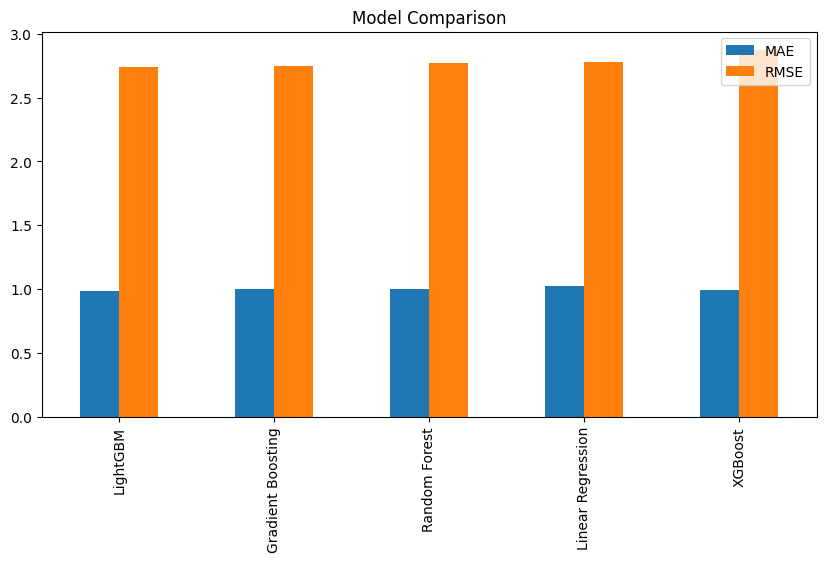

In [58]:
results_df.sort_values("RMSE").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison")
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1811
[LightGBM] [Info] Number of data points in the train set: 2945334, number of used features: 22
[LightGBM] [Info] Start training from score 1.213105


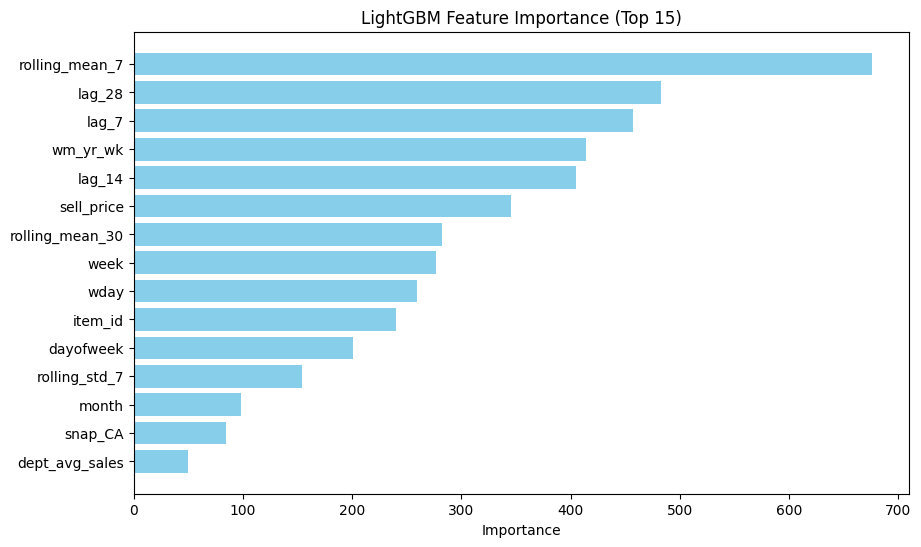

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Example with LightGBM
best_model_name = "LightGBM"
best_model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

# Fit on the full training data
best_model_pipeline.fit(X_train, y_train)

# Extract model from pipeline
model = best_model_pipeline.named_steps['model']

# Get feature importance
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    feature_names = X_train.columns
    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    # Plot top 15 features
    plt.figure(figsize=(10,6))
    plt.barh(feat_imp['feature'][:15][::-1], feat_imp['importance'][:15][::-1], color='skyblue')
    plt.title(f'{best_model_name} Feature Importance (Top 15)')
    plt.xlabel('Importance')
    plt.show()

/opt/anaconda3/envs/recsys/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


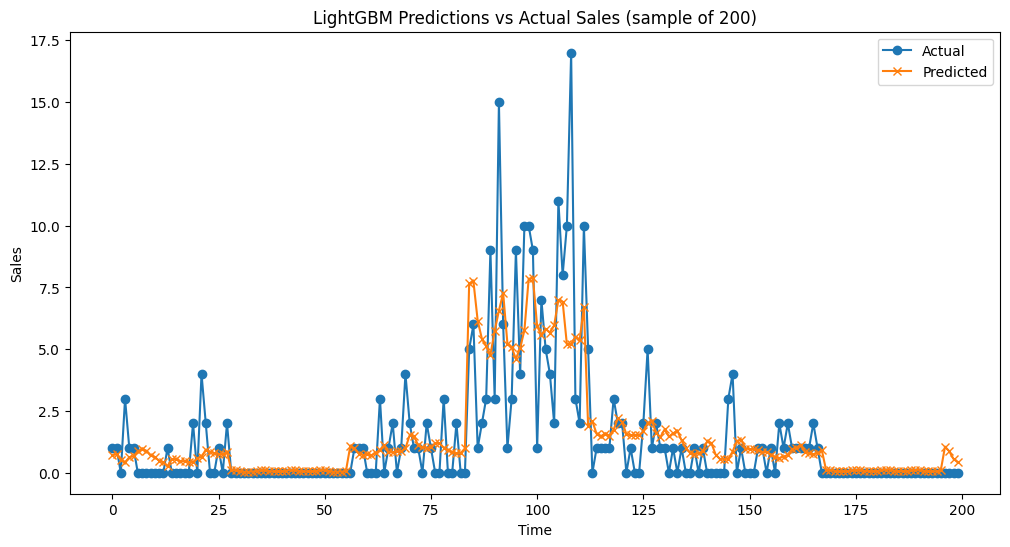

In [60]:
# Predict on test set
preds = best_model_pipeline.predict(X_test)

plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label='Actual', marker='o')  # first 200 points
plt.plot(preds[:200], label='Predicted', marker='x')
plt.title(f'{best_model_name} Predictions vs Actual Sales (sample of 200)')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063273 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1811
[LightGBM] [Info] Number of data points in the train set: 2945334, number of used features: 22
[LightGBM] [Info] Start training from score 1.213105


/opt/anaconda3/envs/recsys/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


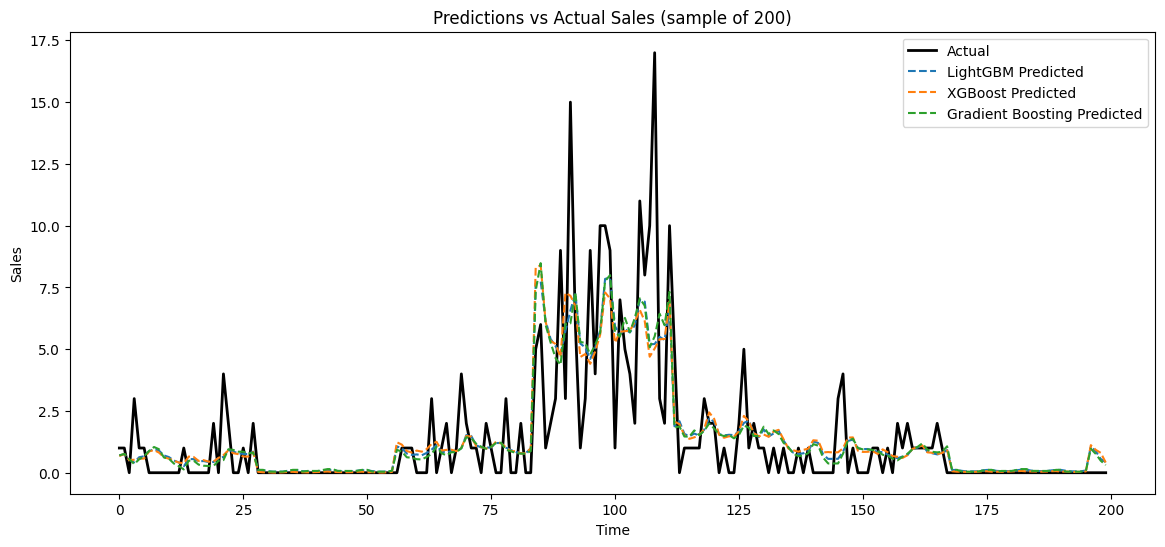

In [61]:
import matplotlib.pyplot as plt

top_models = ["LightGBM", "XGBoost", "Gradient Boosting"]

plt.figure(figsize=(14,6))

# Take a sample to keep plot readable (e.g., first 200 points)
sample_size = 200
x_axis = range(sample_size)

# Plot actual sales
plt.plot(x_axis, y_test.values[:sample_size], label="Actual", color='black', linewidth=2)

# Plot predictions for each model
for model_name in top_models:
    # Build pipeline
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", models[model_name])
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    plt.plot(x_axis, preds[:sample_size], label=f"{model_name} Predicted", linestyle='--')

plt.title("Predictions vs Actual Sales (sample of 200)")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1811
[LightGBM] [Info] Number of data points in the train set: 2945334, number of used features: 22
[LightGBM] [Info] Start training from score 1.213105


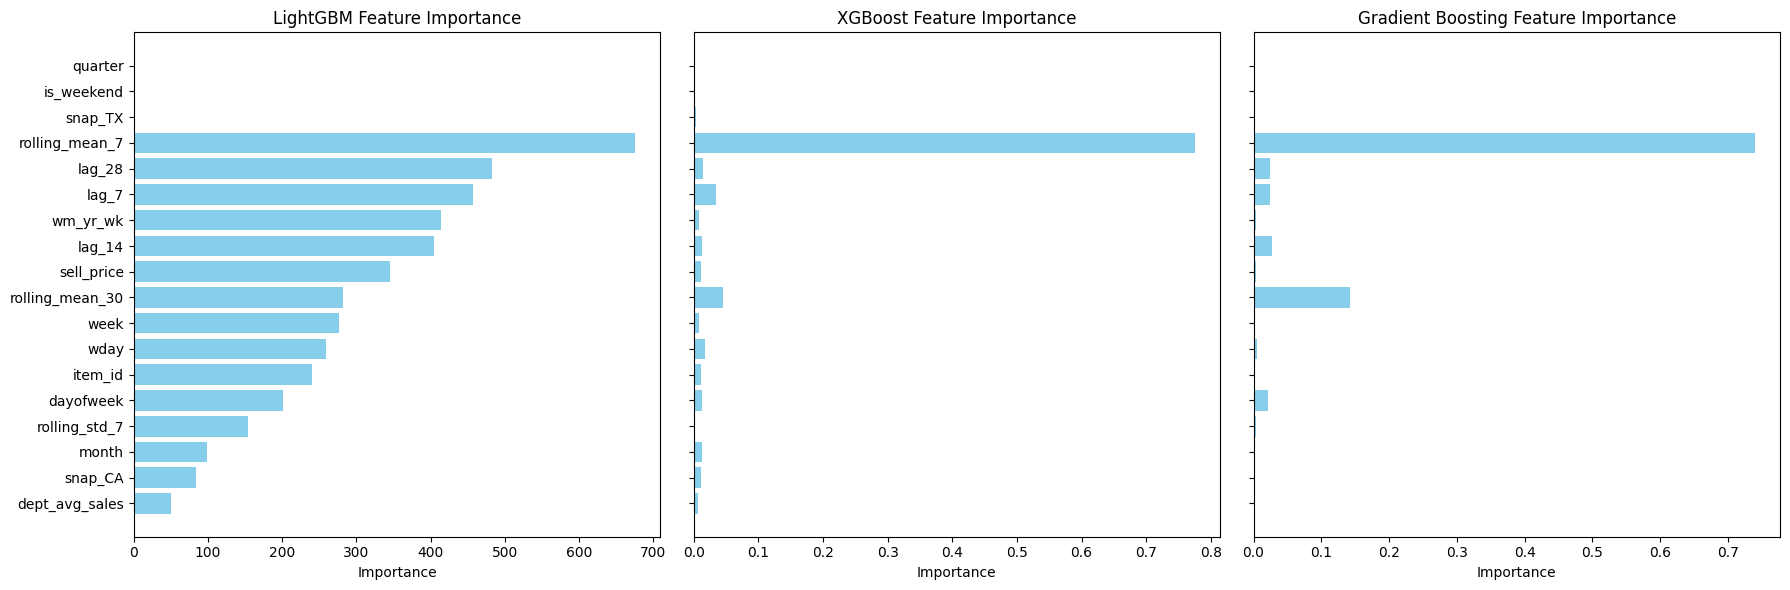

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

top_models = ["LightGBM", "XGBoost", "Gradient Boosting"]
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

for i, model_name in enumerate(top_models):
    # Build pipeline
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", models[model_name])
    ])
    pipe.fit(X_train, y_train)
    
    # Extract model from pipeline
    model = pipe.named_steps['model']
    
    # Only tree-based models have feature_importances_
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feat_imp = pd.DataFrame({
            'feature': X_train.columns,
            'importance': importances
        }).sort_values(by='importance', ascending=False).head(15)
        
        # Plot horizontal bar chart
        axes[i].barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1], color='skyblue')
        axes[i].set_title(f"{model_name} Feature Importance")
        axes[i].set_xlabel("Importance")
    else:
        axes[i].text(0.5, 0.5, 'No feature importance', horizontalalignment='center', verticalalignment='center')
        axes[i].set_title(model_name)

plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [64]:
#LightGBM Hyperparameter Tuning

In [65]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

# Define hyperparameter space
lgb_params = {
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

lgb_model = lgb.LGBMRegressor(random_state=42)

lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_params,
    n_iter=20,           # Number of random combinations to try
    cv=3,                # 3-fold cross-validation
    scoring='neg_mean_absolute_error',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit search on preprocessed features
lgb_search.fit(X_train, y_train)

print("Best LightGBM params:", lgb_search.best_params_)
print("Best MAE:", -lgb_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.670027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1747
[LightGBM] [Info] Number of data points in the train set: 1963556, number of used features: 22
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.704709 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1823
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.384557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1823
[LightGBM] [Info] Number of data points in the train set: 1963556, number of used features: 22
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.381335 se

In [66]:
#Gradient Boosting (sklearn) Hyperparameter Tuning

In [71]:
from sklearn.ensemble import GradientBoostingRegressor

X_sample = X_train.sample(n=100000, random_state=42)
y_sample = y_train.loc[X_sample.index]

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'max_features': ['sqrt']  
}

# Build model
gb_model = GradientBoostingRegressor(random_state=42)

# RandomizedSearchCV
gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_params,
    n_iter=10,           
    cv=2,          
    scoring='neg_mean_absolute_error',
    verbose=2,
    n_jobs=-1,          
    random_state=42
)

# Fit search on sample
gb_search.fit(X_sample, y_sample)

# Best parameters and MAE
print("Best Gradient Boosting params:", gb_search.best_params_)
print("Best MAE on sample:", -gb_search.best_score_)

# Retrain GB on full dataset with best params
best_gb = GradientBoostingRegressor(
    **gb_search.best_params_,
    random_state=42
)

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),  # your preprocessing steps
    ("model", best_gb)
])

gb_pipeline.fit(X_train, y_train)


print("Best Gradient Boosting params:", gb_search.best_params_)
print("Best MAE:", -gb_search.best_score_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, n_estimators=100, subsample=0.8; total time=   2.4s
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, n_estimators=100, subsample=0.8; total time=   2.5s
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, n_estimators=100, subsample=1.0; total time=   2.5s
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, n_estimators=100, subsample=1.0; total time=   2.6s
[CV] END learning_rate=0.05, max_depth=5, max_features=sqrt, n_estimators=100, subsample=1.0; total time=   3.8s
[CV] END learning_rate=0.05, max_depth=5, max_features=sqrt, n_estimators=100, subsample=1.0; total time=   3.9s
[CV] END learning_rate=0.1, max_depth=5, max_features=sqrt, n_estimators=100, subsample=1.0; total time=   3.5s
[CV] END learning_rate=0.1, max_depth=5, max_features=sqrt, n_estimators=100, subsample=1.0; total time=   3.6s
[CV] END learning_rate=0.1, max_depth

In [72]:
# Example tuned parameters (replace with your RandomizedSearchCV best_params)
best_params_lgb = {
    'num_leaves': 50,
    'max_depth': 20,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

best_params_gb = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'max_features': 0.8
}

In [74]:
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb
from sklearn.pipeline import Pipeline

# Create pipelines with preprocessor
lgb_model = lgb.LGBMRegressor(**best_params_lgb, random_state=42)
gb_model = GradientBoostingRegressor(**best_params_gb, random_state=42)

pipelines = {
    "LightGBM": Pipeline([("preprocessor", preprocessor), ("model", lgb_model)]),
    "Gradient Boosting": Pipeline([("preprocessor", preprocessor), ("model", gb_model)])
}

# Fit both models
for name, pipe in pipelines.items():
    print(f"Training {name} on full training data...")
    pipe.fit(X_train, y_train)

Training LightGBM on full training data...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1827
[LightGBM] [Info] Number of data points in the train set: 2945334, number of used features: 22
[LightGBM] [Info] Start training from score 1.213105
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training Gradient Boosting on full training data...


/opt/anaconda3/envs/recsys/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM -> MAE: 0.9853, RMSE: 2.7735
Gradient Boosting -> MAE: 0.9909, RMSE: 2.8246


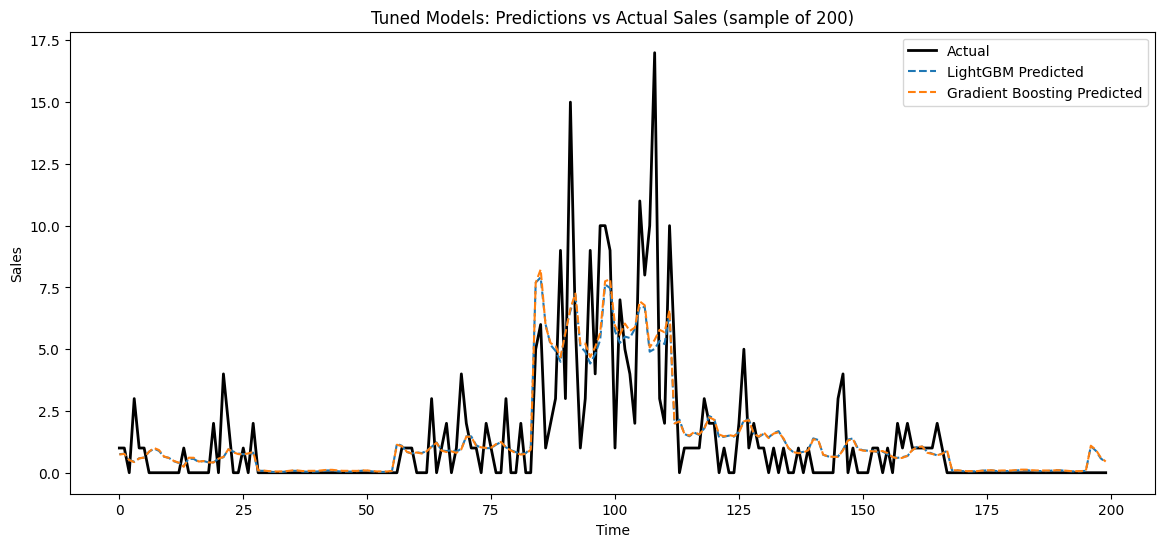

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sample_size = 200  # first 200 points for visualization
x_axis = range(sample_size)

plt.figure(figsize=(14,6))
plt.plot(x_axis, y_test.values[:sample_size], label='Actual', color='black', linewidth=2)

for name, pipe in pipelines.items():
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    plt.plot(x_axis, preds[:sample_size], linestyle='--', label=f"{name} Predicted")

plt.title("Tuned Models: Predictions vs Actual Sales (sample of 200)")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

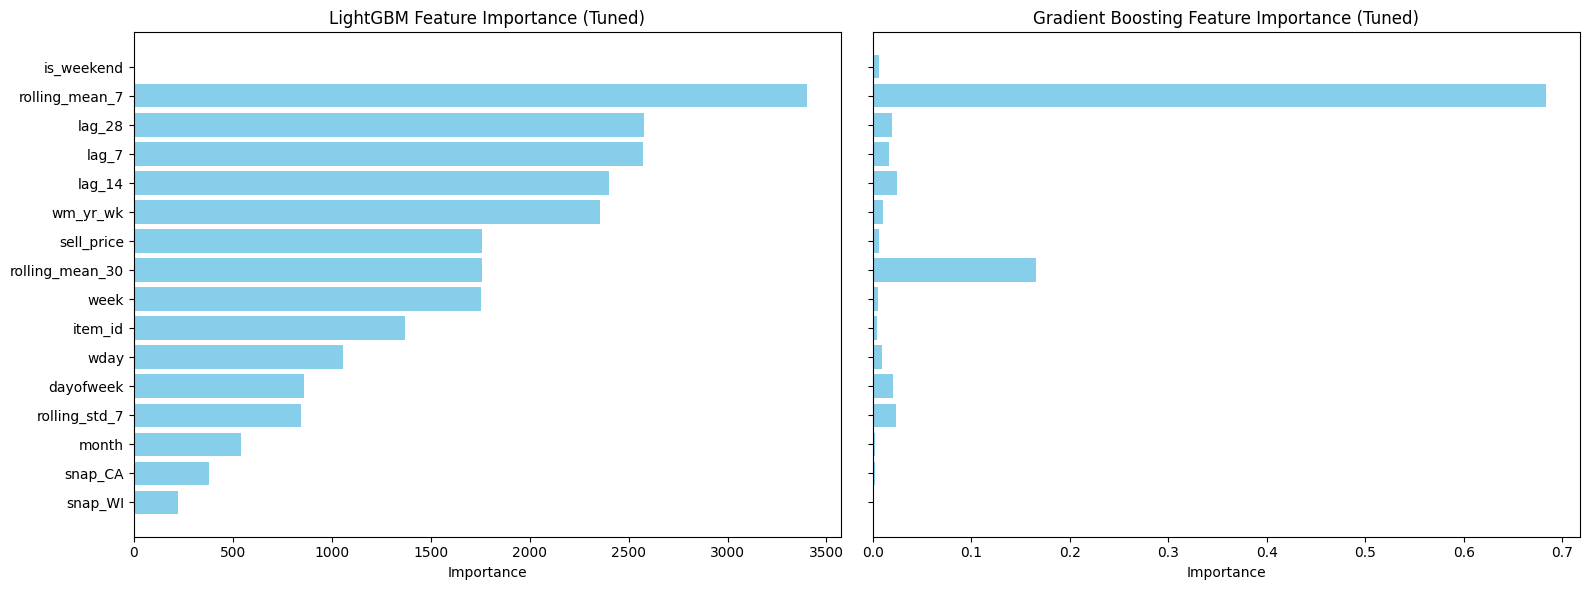

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

for i, (name, pipe) in enumerate(pipelines.items()):
    model = pipe.named_steps['model']
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feat_imp = pd.DataFrame({
            'feature': X_train.columns,
            'importance': importances
        }).sort_values(by='importance', ascending=False).head(15)
        axes[i].barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1], color='skyblue')
        axes[i].set_title(f"{name} Feature Importance (Tuned)")
        axes[i].set_xlabel("Importance")
    else:
        axes[i].text(0.5, 0.5, 'No feature importance', ha='center', va='center')
        axes[i].set_title(name)

plt.tight_layout()
plt.show()

In [80]:
import joblib

for name, pipe in pipelines.items():
    filename = f"{name.replace(' ', '_')}_tuned_model.pkl"
    joblib.dump(pipe, filename)
    print(f"Saved {name} tuned model as {filename}")

Saved LightGBM tuned model as LightGBM_tuned_model.pkl
Saved Gradient Boosting tuned model as Gradient_Boosting_tuned_model.pkl
